In [1]:
import jcopdl, luwiji
jcopdl.__version__,luwiji.__version__

('1.1.10', '1.2.3')

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [42]:
import torch
from torch import nn, optim
from jcopdl.callback import Callback, set_config

device = torch.device("cuda:0" if torch.cuda.is_available()else "cpu")
device

device(type='cpu')

# Dataset dan Dataloder

#dibawah ini standar jika kita main di iamge recognation bukan objek detection dan juga bukan image segmentation

In [43]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [44]:
# Parameter
bs = 64  # Ukuran batch dikurangi biar lebih ringan
crop_size = 64

# Transformasi untuk data latih
train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(crop_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

# Transformasi untuk data uji
test_transform = transforms.Compose([
    transforms.Resize(70),
    transforms.CenterCrop(crop_size),
    transforms.ToTensor()
])

# Dataset dan DataLoader
train_set = datasets.ImageFolder("data/train/", transform=train_transform)
trainloader = DataLoader(
    train_set, batch_size=bs, shuffle=True, num_workers=0, pin_memory=False
)

test_set = datasets.ImageFolder("data/test/", transform=test_transform)
testloader = DataLoader(
    test_set, batch_size=bs, shuffle=False, num_workers=0, pin_memory=False
)


# Arsitektur & Config

In [45]:
# di bawah ini kalau mau manual tampa Block

# nn.Conv2d(3, 8, 3, 1, 1),
# nn.Relu(),
# nn.MaxPool2d(2, 2)

# kalau mau cepet pakai library aja udah di bungkus biar rapi

In [46]:
from jcopdl.layers import conv_block
from jcopdl.layers import linear_block

In [47]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Feature extractor
        self.conv = nn.Sequential(
            conv_block(3,   8),
            conv_block(8,  16),
            conv_block(16, 32),
            conv_block(32, 64),
            nn.Flatten()
        )

        # Classifier
        self.fc = nn.Sequential(
            linear_block(1024, 256, dropout=0.1),
            linear_block(256, 2, activation="lsoftmax")  # log‑softmax
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [48]:

config = set_config({
    "batch_size": bs,
    "crop_size":crop_size
})

# Training Prepration -> MCOC

In [49]:
model = CNN().to(device)
criterion = nn.NLLLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)
callback = Callback(model, config, outdir="model")

# Training

In [50]:
from tqdm.auto import  tqdm # melihat kita tahu ngeheng atau gak
def loop_fn(mode, dataset, dataloader, model, criterion, optimizer, device):
    if mode == "train":
        model.train()
    elif mode == "test":
        model.eval()
    
    cost = correct = 0
    for feature, target in tqdm (dataloader, desc=mode.title()):
        feature, target = feature.to(device), target.to(device)
        output = model(feature)
        loss = criterion(output, target)

        if mode == "train":
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        cost += loss.item() * feature.shape[0]
        correct += (output.argmax(1) == target).sum().item()

    cost = cost / len(dataset)
    acc = correct / len(dataset)
    return cost, acc

Train:   0%|          | 0/16 [00:00<?, ?it/s]

Test:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch     1
Train_cost  = 0.6944 | Test_cost  = 0.6841 | Train_score = 0.4880 | Test_score = 0.6850 |


Train:   0%|          | 0/16 [00:00<?, ?it/s]

Test:   0%|          | 0/7 [00:00<?, ?it/s]

...

Test:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch    19
Train_cost  = 0.3507 | Test_cost  = 0.3718 | Train_score = 0.8480 | Test_score = 0.8475 |
==> EarlyStop patience =  4 | Best test_score: 0.8625


Train:   0%|          | 0/16 [00:00<?, ?it/s]

Test:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch    20
Train_cost  = 0.3487 | Test_cost  = 0.3111 | Train_score = 0.8530 | Test_score = 0.8800 |


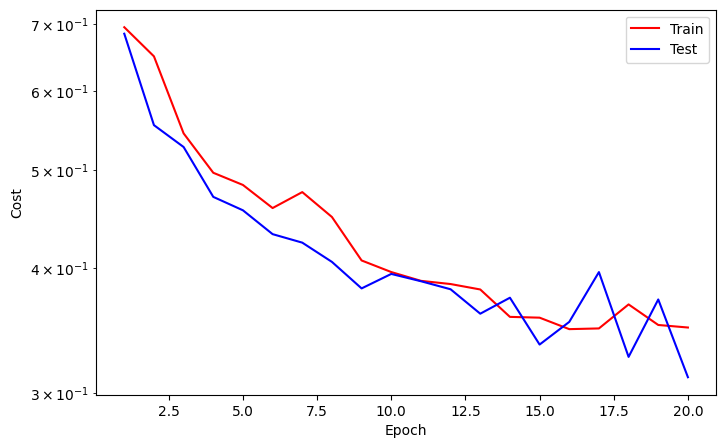

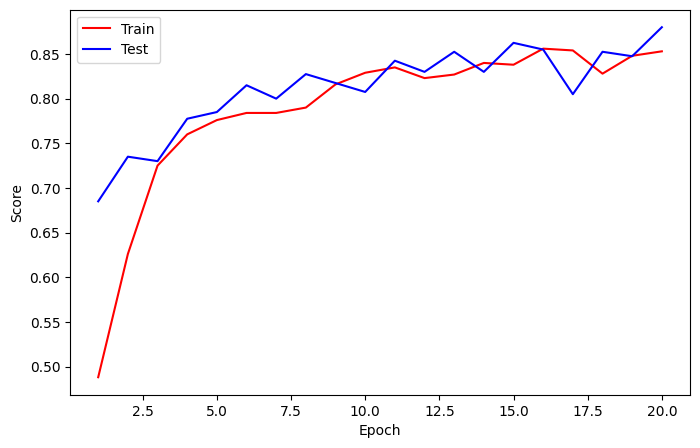

Train:   0%|          | 0/16 [00:00<?, ?it/s]

Test:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch    21
Train_cost  = 0.3290 | Test_cost  = 0.3253 | Train_score = 0.8590 | Test_score = 0.8700 |
==> EarlyStop patience =  1 | Best test_score: 0.8800


Train:   0%|          | 0/16 [00:00<?, ?it/s]

Test:   0%|          | 0/7 [00:00<?, ?it/s]

...

Test:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch    39
Train_cost  = 0.2497 | Test_cost  = 0.2572 | Train_score = 0.8990 | Test_score = 0.9050 |
==> EarlyStop patience =  1 | Best test_score: 0.9125


Train:   0%|          | 0/16 [00:00<?, ?it/s]

Test:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch    40
Train_cost  = 0.2277 | Test_cost  = 0.2773 | Train_score = 0.9010 | Test_score = 0.8950 |


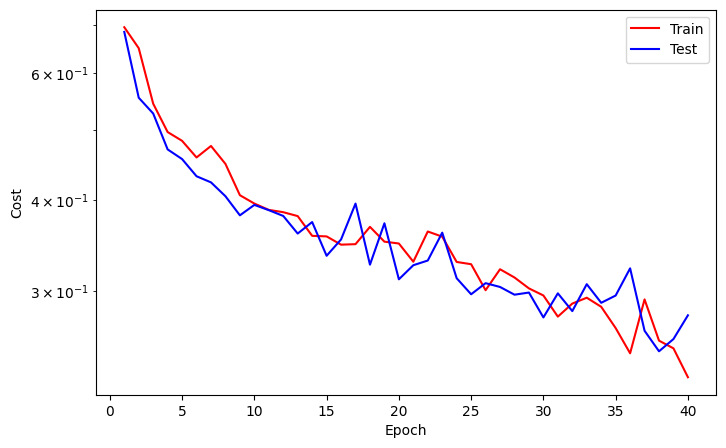

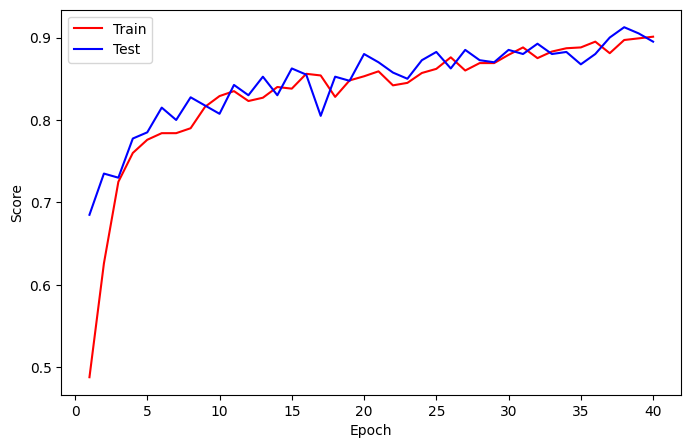

==> EarlyStop patience =  2 | Best test_score: 0.9125


Train:   0%|          | 0/16 [00:00<?, ?it/s]

Test:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch    41
Train_cost  = 0.2325 | Test_cost  = 0.2509 | Train_score = 0.9070 | Test_score = 0.9050 |
==> EarlyStop patience =  3 | Best test_score: 0.9125


Train:   0%|          | 0/16 [00:00<?, ?it/s]

...


Epoch    42
Train_cost  = 0.2335 | Test_cost  = 0.3116 | Train_score = 0.9010 | Test_score = 0.8625 |
==> EarlyStop patience =  4 | Best test_score: 0.9125


Train:   0%|          | 0/16 [00:00<?, ?it/s]

Test:   0%|          | 0/7 [00:00<?, ?it/s]


Epoch    43
Train_cost  = 0.2360 | Test_cost  = 0.2368 | Train_score = 0.9070 | Test_score = 0.9100 |
==> EarlyStop patience =  5 | Best test_score: 0.9125
==> Execute Early Stopping at epoch: 43 | Best test_score: 0.9125
==> Best model is saved at model


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\jcopdl\callback\_callback.py:104: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  weights = torch.load(

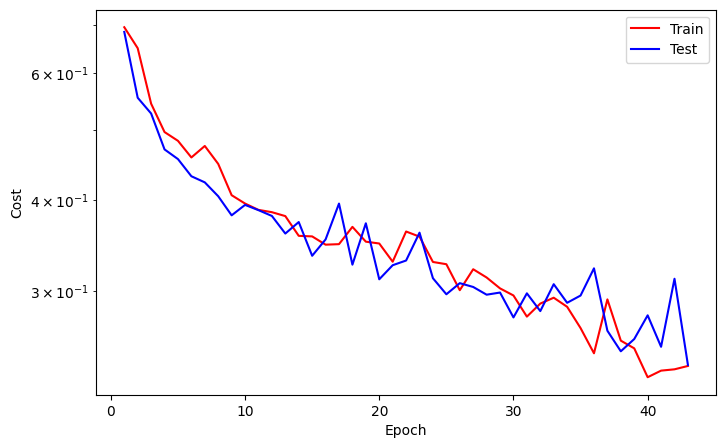

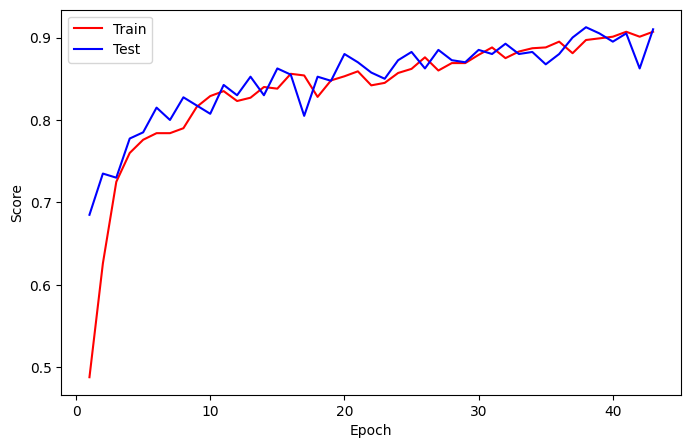

In [51]:
while True: # looping tak terhingga kali
    train_cost, train_score = loop_fn("train", train_set, trainloader, model, criterion, optimizer, device)
    with torch.no_grad():
        test_cost, test_score = loop_fn("test", test_set, testloader, model, criterion, optimizer, device)

    # Logging
    callback.log(train_cost, test_cost, train_score, test_score)

    # Checkpoint
    callback.save_checkpoint()

    # Runtime Plotting
    callback.cost_runtime_plotting()
    callback.score_runtime_plotting()

    # Early Stopping
    if callback.early_stopping(model, monitor="test_score"):
        callback.plot_cost()
        callback.plot_score()
        break


# Predict

In [52]:
feature, target = next(iter(testloader))
faeture, target = feature.to(device), target.to(device)

In [53]:
with torch.no_grad():
    model.eval()
    output = model(feature)
    preds = output.argmax(1)
print(preds.tolist())


[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


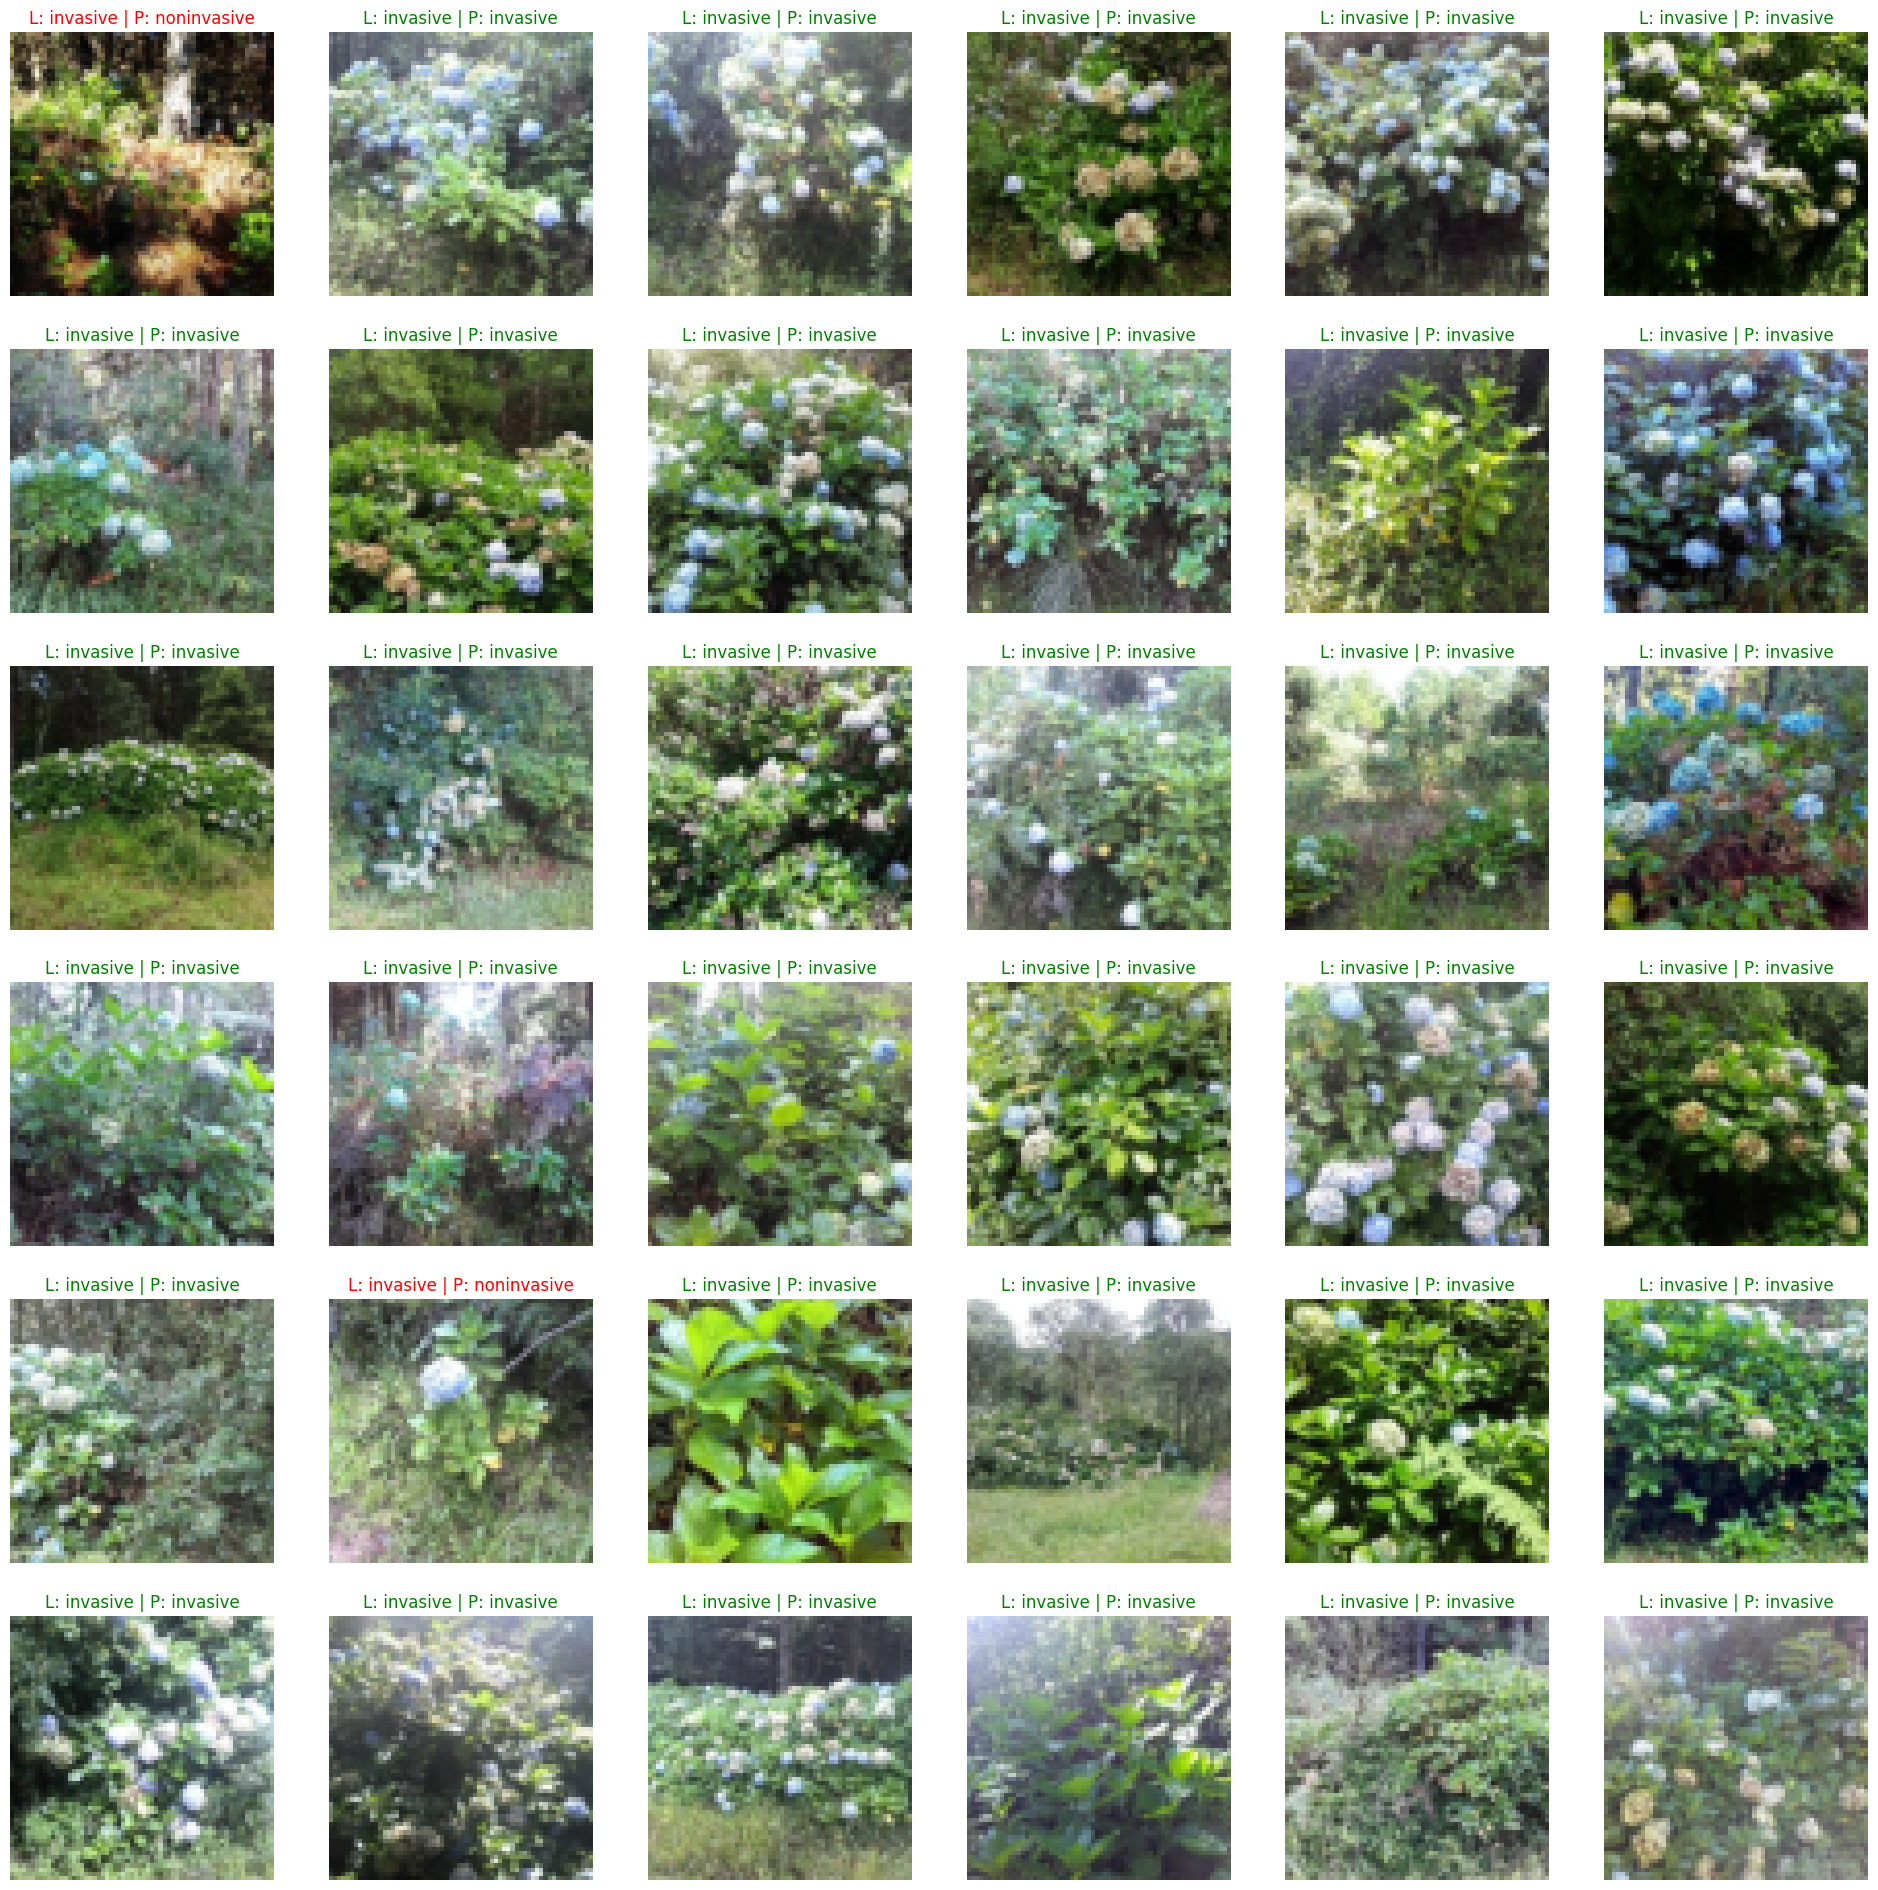

In [54]:
# Buat mapping index → nama kelas
label2cat = train_set.classes

# Plot
fig, axes = plt.subplots(6, 6, figsize=(24, 24))

for image, label, pred, ax in zip(feature, target, preds, axes.flatten()):
    ax.imshow(image.permute(1, 2, 0).cpu())

    # Warna font: merah jika salah, hijau jika benar
    font = {"color": 'r'} if label != pred else {"color": 'g'}

    # Konversi ke string nama kelas
    label_str = label2cat[label.item()]
    pred_str = label2cat[pred.item()]

    # Set judul
    ax.set_title(f"L: {label_str} | P: {pred_str}", fontdict=font)
    ax.axis('off')
